In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [5]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [6]:
X

array([[-10.86482449,   7.71997641],
       [ -3.95098563,   6.55425208],
       [ -8.85513613,   8.96652419],
       ...,
       [ -2.12547514,   8.49712929],
       [ -2.48195681,   9.93368169],
       [ -7.94273165,   8.34976293]], shape=(1000, 2))

In [7]:
y

array([0, 2, 0, 1, 0, 2, 1, 0, 1, 0, 2, 2, 2, 1, 1, 0, 1, 0, 1, 0, 1, 2,
       2, 1, 1, 0, 2, 1, 2, 1, 0, 0, 2, 0, 1, 2, 0, 2, 1, 2, 2, 1, 0, 0,
       0, 2, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 2, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 0, 1, 0, 2, 1, 2, 0, 2, 0, 2, 1, 2,
       1, 2, 2, 2, 0, 0, 1, 1, 2, 0, 0, 0, 1, 1, 1, 2, 1, 0, 0, 2, 1, 1,
       0, 2, 0, 2, 2, 1, 2, 2, 2, 0, 2, 2, 0, 1, 2, 2, 1, 0, 1, 2, 2, 2,
       2, 1, 1, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 1, 1, 2, 1, 2, 1, 2, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 2, 1, 2, 1, 0, 0, 2, 1, 1, 2,
       1, 1, 1, 0, 0, 2, 2, 2, 0, 0, 1, 2, 0, 0, 1, 2, 0, 0, 2, 1, 0, 0,
       0, 0, 1, 2, 0, 0, 1, 0, 1, 0, 2, 2, 1, 1, 1, 2, 0, 1, 1, 0, 1, 2,
       1, 0, 2, 0, 0, 0, 0, 2, 2, 1, 2, 0, 1, 0, 2, 0, 1, 2, 1, 1, 0, 2,
       2, 2, 2, 2, 0, 0, 2, 2, 0, 1, 2, 1, 1, 1, 0, 1, 1, 2, 2, 0, 0, 1,
       0, 1, 2, 0, 0, 2, 1, 2, 0, 1, 2, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 2, 0, 0, 2, 0, 0, 1, 2, 2, 2, 0, 2, 1,

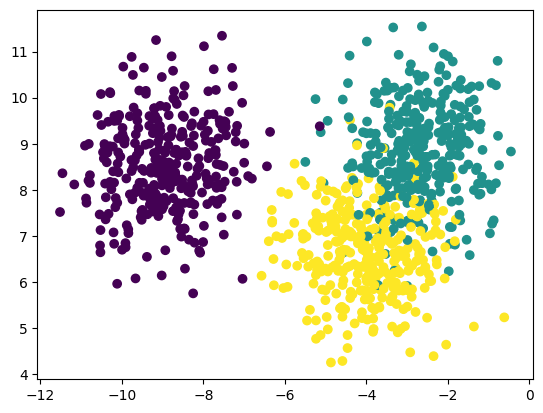

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)

In [9]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [12]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [13]:
from sklearn.cluster import KMeans

In [14]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [15]:
wcss

[1340.0000000000014,
 728.2651448063677,
 347.2446599756273,
 278.8057469365575,
 241.2218704994851,
 186.97578374905223,
 154.73072219392193,
 141.11004340004675,
 123.74683874806902,
 117.9864692168688]

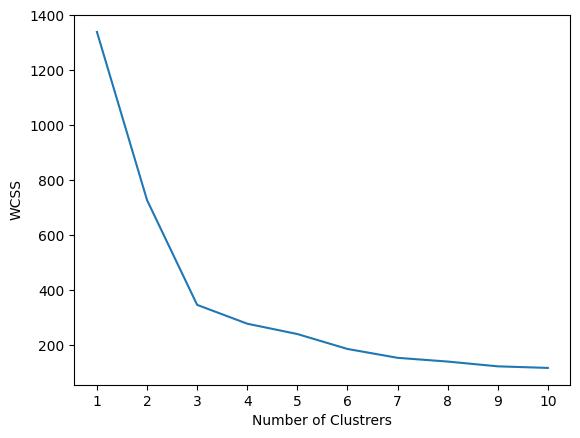

In [22]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [28]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [29]:
kmeans.fit_predict(X_train_scaled)

array([1, 1, 0, 0, 0, 1, 0, 2, 2, 2, 2, 0, 1, 1, 2, 0, 0, 0, 1, 2, 1, 1,
       0, 2, 1, 1, 2, 2, 1, 0, 1, 2, 2, 2, 2, 2, 1, 0, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 1, 1, 1, 0, 1, 2, 2, 0, 2, 2, 2, 1, 1,
       0, 2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 1, 2, 0, 2, 0, 0, 0, 1, 2, 1, 0,
       0, 2, 1, 2, 0, 2, 0, 0, 1, 0, 2, 0, 2, 1, 0, 2, 2, 1, 1, 2, 1, 1,
       0, 1, 2, 0, 2, 0, 1, 2, 2, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 2, 1,
       0, 1, 0, 2, 1, 0, 1, 1, 0, 0, 0, 1, 2, 0, 1, 0, 2, 1, 1, 2, 1, 0,
       2, 0, 0, 2, 2, 2, 2, 1, 0, 1, 0, 2, 1, 0, 0, 2, 1, 2, 0, 0, 2, 0,
       2, 1, 1, 2, 2, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 0, 2, 1, 1, 1, 0,
       2, 0, 2, 2, 0, 2, 1, 0, 1, 2, 2, 1, 0, 1, 2, 0, 1, 1, 2, 2, 2, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 2, 1, 2, 0, 2, 1, 2, 0, 1, 0, 1, 1, 1, 1,
       1, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1,
       2, 2, 0, 1, 2, 2, 0, 0, 0, 2, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 1, 1,
       1, 2, 1, 1, 0, 0, 1, 0, 2, 2, 2, 2, 0, 2, 1,

In [30]:
y_pred=kmeans.predict(X_test_scaled)

In [31]:
y_pred

array([2, 2, 0, 2, 2, 0, 0, 1, 2, 1, 1, 0, 2, 0, 2, 0, 0, 0, 1, 1, 1, 2,
       0, 1, 1, 0, 2, 0, 2, 0, 0, 0, 2, 1, 1, 0, 0, 2, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 2, 1, 0, 0, 2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 1, 0,
       0, 2, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 2, 2, 2, 0, 0, 2, 0,
       0, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1, 0, 2, 0, 2, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 2, 0, 0, 0, 0, 2, 1, 2, 1, 1, 1, 2, 2, 0, 1, 1, 1, 2,
       2, 1, 1, 0, 1, 2, 0, 0, 0, 0, 2, 0, 1, 2, 0, 1, 1, 2, 1, 2, 2, 2,
       0, 2, 2, 0, 1, 2, 1, 0, 0, 1, 2, 2, 0, 1, 2, 2, 2, 2, 0, 1, 2, 1,
       1, 1, 0, 2, 1, 1, 0, 2, 0, 1, 0, 1, 1, 1, 1, 0, 2, 0, 1, 1, 2, 1,
       1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 2, 1, 0, 1, 1, 0, 0, 0, 1, 2, 0, 1,
       0, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 1, 2, 0, 2, 0, 2, 0, 0, 1, 0, 0, 2, 1, 0, 2, 1, 0, 1, 0, 1,
       2, 0, 1, 2, 2, 2, 1, 1, 1, 0, 2, 0, 0, 1, 1, 1, 1, 1, 2, 0, 2, 0,
       0, 2, 1, 0, 0, 2, 2, 2, 1, 2, 1, 2, 0, 2, 2,

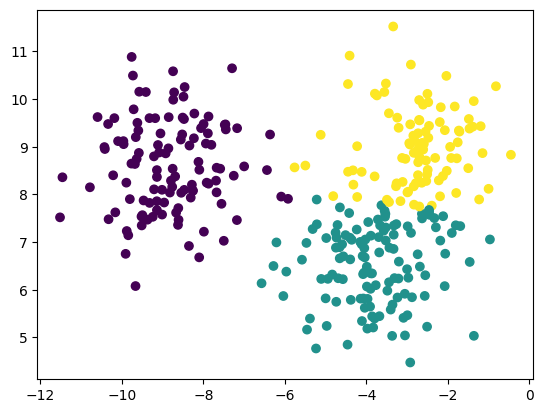

In [32]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [33]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [34]:
from kneed import KneeLocator

In [35]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [36]:
kl.elbow

np.int64(3)

In [37]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [38]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [39]:
silhouette_coefficients

[0.47320400316152206,
 0.5299441032079298,
 0.45834439371214053,
 0.41522036529621886,
 0.3820258771449193,
 0.35788293605858557,
 0.3542764784007432,
 0.3539098834957392,
 0.3355362808111956]

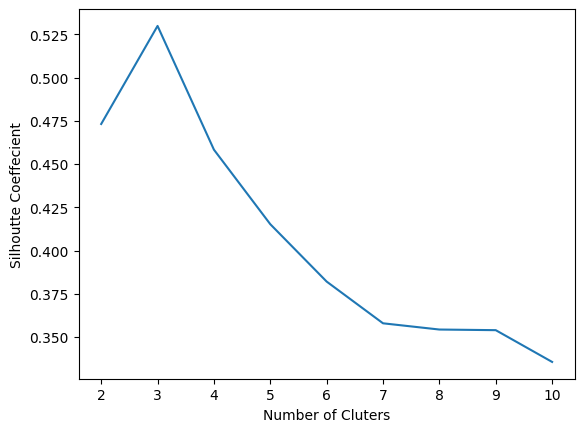

In [40]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()